In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dp=pd.read_csv('/content/student_data.csv',encoding='iso-8859-1')
dp

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [3]:
dp.rename(columns={'IsFirstChild':'FirstChild','ParentMaritalStatus':'ParentMarital'},inplace=True)

In [4]:
dp['Gender']=dp['Gender'].str.title()

In [5]:
dp.drop_duplicates()
dp.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMarital,PracticeSport,FirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,Female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,Female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,Female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,Male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,Male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [6]:
dp.dropna()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMarital,PracticeSport,FirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
2,2,Female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
4,4,Male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
5,5,Female,group B,associate's degree,standard,none,married,regularly,yes,1.0,school_bus,5 - 10,73,84,79
6,6,Female,group B,some college,standard,completed,widowed,never,no,1.0,private,5 - 10,85,93,89
7,7,Male,group B,some college,free/reduced,none,married,sometimes,yes,1.0,private,> 10,41,43,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30635,794,Male,group C,some college,standard,none,married,regularly,no,2.0,school_bus,5 - 10,58,53,49
30636,816,Female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,Male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30639,934,Female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [7]:
dp['AverageScore'] = dp[['MathScore', 'ReadingScore', 'WritingScore']].mean(axis=1)

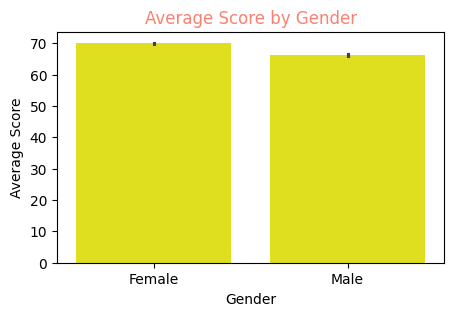

In [8]:
#Gender vs Average Score
plt.figure(figsize=(5,3))
sns.barplot(data=dp, x='Gender', y='AverageScore',color='yellow')
plt.title('Average Score by Gender',color='#fa8072')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.show()


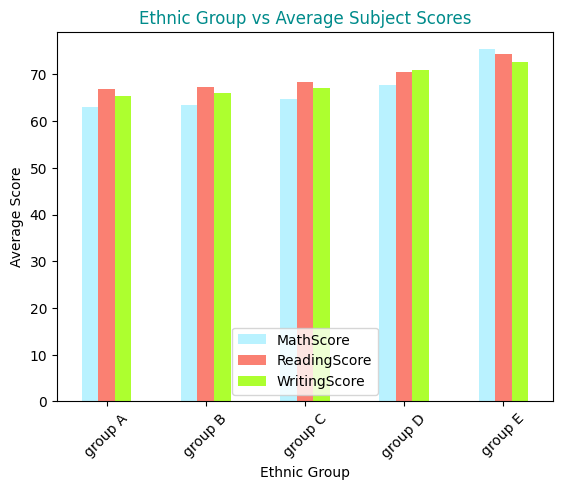

In [9]:
#Ethnic Group vs Performance

ethnic_avg = dp.groupby('EthnicGroup')[['MathScore','ReadingScore','WritingScore']].mean()

ethnic_avg.plot(kind='bar',color=['#b9f2ff','#fa8072','#adff2f'])
plt.title('Ethnic Group vs Average Subject Scores',color='#008b8b')
plt.xlabel('Ethnic Group')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.show()


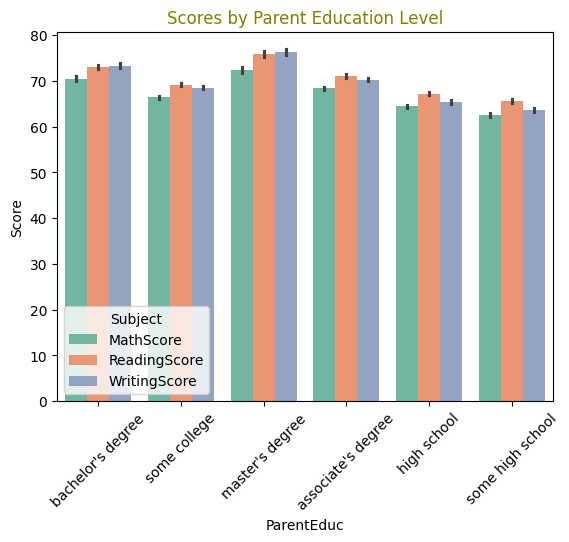

In [10]:
#Parent Education vs Scores
df_melt = dp.melt(
    id_vars='ParentEduc',
    value_vars=['MathScore', 'ReadingScore', 'WritingScore'],
    var_name='Subject',
    value_name='Score'
)

sns.barplot(data=df_melt, x='ParentEduc', y='Score', hue='Subject',palette='Set2')
plt.title('Scores by Parent Education Level',color='#808000')
plt.xticks(rotation=45)
plt.show()


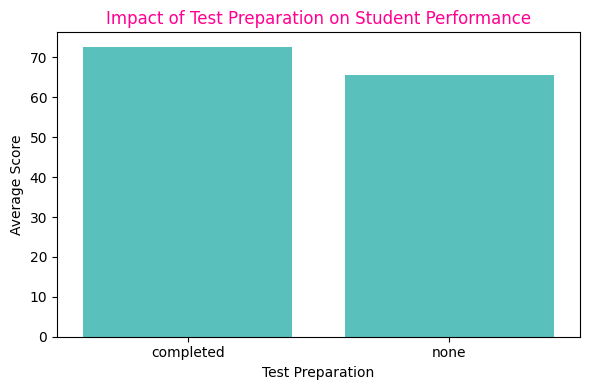

In [11]:
#Test Preparation
testprep_mean = dp.groupby('TestPrep')['AverageScore'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=testprep_mean,x='TestPrep',y='AverageScore',errorbar=None,color='#48d1cc')
plt.title('Impact of Test Preparation on Student Performance',color='#ff0090')
plt.xlabel('Test Preparation')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()




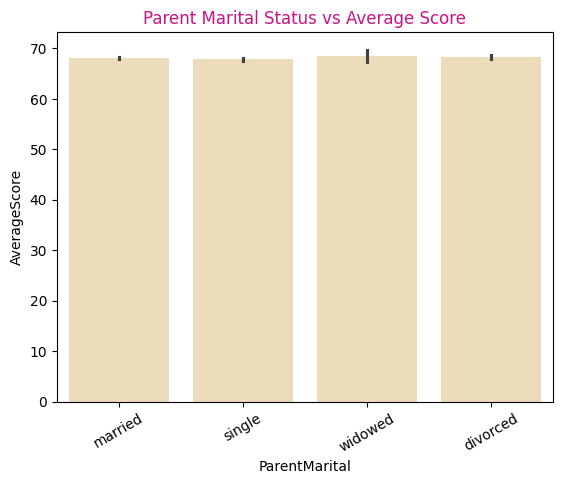

In [12]:
#Parent Marital Status Impact
sns.barplot(data=dp, x='ParentMarital', y='AverageScore',color='#f5deb3')
plt.title('Parent Marital Status vs Average Score',color='#c71585')
plt.xticks(rotation=30)
plt.show()


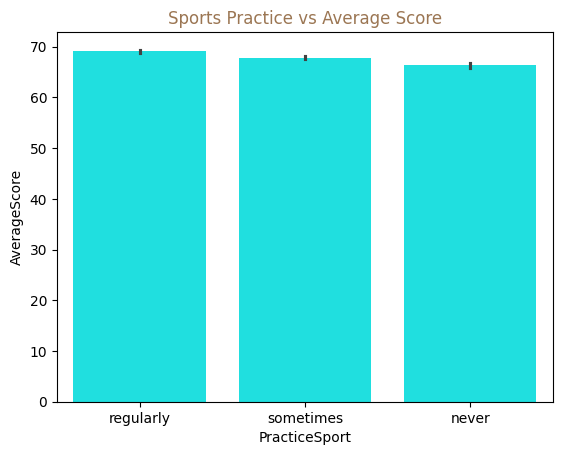

In [13]:
#Sports Practice Impact
sns.barplot(data=dp, x='PracticeSport', y='AverageScore',color='#00ffff')
plt.title('Sports Practice vs Average Score',color='#9b7653')
plt.show()


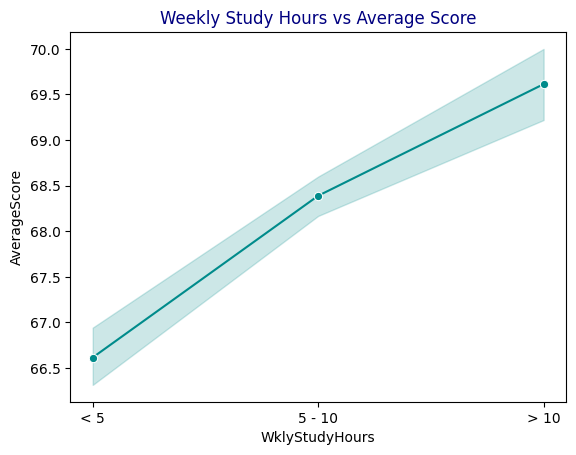

In [14]:
#Weekly Study Hours vs Average Score
sns.lineplot(data=dp, x='WklyStudyHours', y='AverageScore', marker='o',color='#008b8b')
plt.title('Weekly Study Hours vs Average Score',color='#000080')
plt.show()
